# Clean data and process

In [89]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== User settings =====
base_dir = Path(r"D:\Arduino\Physic2 project\Data processing\Data Session use!!!!")   # change if needed
min_runtime_s = 29.0                                    # keep only runs >= this
exclude_transient_s_start = 3.0                         # remove first few seconds in averaging
exclude_transient_s_end = 2.0                           # remove last few seconds in averaging
use_absolute_thrust = True                              # compare thrust magnitude

# Optional manual order for nicer plots
condition_order = ["Without dome", "With dome gina", "With dome Saipan"]

In [90]:
def parse_ts(line):
    m = re.match(r"\[(.*?)\]", line)
    return pd.to_datetime(m.group(1)) if m else pd.NaT

def parse_serial_log(path):
    rows = []
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            ts = parse_ts(line)
            event = None
            value = None

            if "[TX]" in line:
                if "CAL=" in line:
                    event = "CAL"
                    m = re.search(r"CAL=([0-9.]+)", line)
                    value = float(m.group(1)) if m else np.nan
                elif re.search(r"\[TX\]\s*TARE", line):
                    event = "TARE"
                elif re.search(r"\[TX\]\s*SPEED\s+(\d+)", line):
                    event = "SPEED"
                    value = int(re.search(r"\[TX\]\s*SPEED\s+(\d+)", line).group(1))
                elif re.search(r"\[TX\]\s*ON\b", line):
                    event = "ON"
                elif re.search(r"\[TX\]\s*OFF\b", line):
                    event = "OFF"

            if "Motor disabled due to command timeout." in line:
                event = "TIMEOUT"

            rows.append({
                "ts": ts,
                "line": line,
                "event": event,
                "value": value,
            })

    return pd.DataFrame(rows)

def parse_plot_csv(path):
    df = pd.read_csv(path)
    df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")

    for col in ["ms", "time_s", "current_a", "thrust_g"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["thrust_abs_g"] = df["thrust_g"].abs()
    return df.sort_values("pc_time").reset_index(drop=True)

def latest_cal_time(log_df):
    cal = log_df[log_df["event"] == "CAL"]
    return cal["ts"].max() if len(cal) else pd.NaT

In [91]:
def build_control_sessions(log_df, csv_end_ts, analysis_start_ts):
    events = log_df[
        (log_df["ts"] >= analysis_start_ts) &
        (log_df["event"].isin(["ON", "SPEED", "TIMEOUT"]))
    ].sort_values("ts").copy()

    segments = []
    control_session_id = 0

    on_rows = events[events["event"] == "ON"]

    for _, on_row in on_rows.iterrows():
        after_on = events[events["ts"] > on_row["ts"]].copy()

        timeout_rows = after_on[after_on["event"] == "TIMEOUT"]
        end_ts = timeout_rows["ts"].iloc[0] if len(timeout_rows) else csv_end_ts
        end_event = "TIMEOUT" if len(timeout_rows) else "CSV_END"

        speed_rows = after_on[
            (after_on["event"] == "SPEED") &
            (after_on["ts"] < end_ts)
        ].copy()

        # Must have a SPEED after ON, otherwise skip this control session
        if speed_rows.empty:
            continue

        # Use the FIRST SPEED after ON as the true analysis start
        first_speed_row = speed_rows.iloc[0]
        start_ts = first_speed_row["ts"]
        speed_pct = int(first_speed_row["value"]) if pd.notna(first_speed_row["value"]) else np.nan

        runtime_s = (end_ts - start_ts).total_seconds() if pd.notna(end_ts) else np.nan
        control_session_id += 1

        segments.append({
            "control_session_id": control_session_id,
            "start_event": "SPEED",
            "end_event": end_event,
            "on_ts": on_row["ts"],
            "start_ts": start_ts,
            "end_ts": end_ts,
            "runtime_s": runtime_s,
            "speed_pct": speed_pct,
            "all_speed_commands_after_on": ", ".join(
                map(str, speed_rows["value"].dropna().astype(int).tolist())
            ),
            "speed_command_count_after_on": int(len(speed_rows)),
            "qualifies": bool(pd.notna(runtime_s) and runtime_s >= min_runtime_s),
        })

    return pd.DataFrame(segments)

In [92]:
def summarize_segment(segment_df, last_speed_pct, runtime_s, run_id):
    rel_s = (segment_df["pc_time"] - segment_df["pc_time"].iloc[0]).dt.total_seconds()

    stable = segment_df[rel_s >= exclude_transient_s_start].copy()
    if not stable.empty:
        until_end = (segment_df["pc_time"].iloc[-1] - stable["pc_time"]).dt.total_seconds()
        stable = stable[until_end >= exclude_transient_s_end].copy()

    used = stable if len(stable) >= 10 else segment_df.copy()

    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    current = used["current_a"].dropna()
    thrust = used[thrust_col].dropna()

    return {
        "run_id": int(run_id),
        "last_speed_pct": int(last_speed_pct) if pd.notna(last_speed_pct) else np.nan,
        "runtime_s": float(runtime_s),
        "samples_total": int(len(segment_df)),
        "samples_used": int(len(used)),
        "current_mean_A": current.mean(),
        "current_std_A": current.std(),
        "current_min_A": current.min(),
        "current_max_A": current.max(),
        "thrust_mean_g": thrust.mean() if len(thrust) else np.nan,
        "thrust_std_g": thrust.std() if len(thrust) else np.nan,
        "thrust_peak_g": thrust.max() if len(thrust) else np.nan,
        "efficiency_g_per_A": (thrust.mean() / current.mean()) if len(thrust) and current.mean() else np.nan,
    }

In [93]:
def analyze_dataset(base_dir):
    overall_rows = []
    all_control_session_tables = []
    speed_tables = []
    raw_interest = {}

    folders = [p for p in base_dir.iterdir() if p.is_dir()]
    folders = sorted(folders, key=lambda p: p.name)

    for folder in folders:
        condition = folder.name
        log_path = folder / "serial_log.txt"
        csv_path = folder / "plot_data.csv"

        if not log_path.exists() or not csv_path.exists():
            print(f"Skipping {condition}: missing serial_log.txt or plot_data.csv")
            continue

        log_df = parse_serial_log(log_path)
        data_df = parse_plot_csv(csv_path)

        cal_ts = latest_cal_time(log_df)
        analysis_start_ts = cal_ts if pd.notna(cal_ts) else data_df["pc_time"].min()

        segs = build_control_sessions(
            log_df=log_df,
            csv_end_ts=data_df["pc_time"].max(),
            analysis_start_ts=analysis_start_ts,
        )

        frames = []
        session_rows = []

        if len(segs):
            segs.insert(0, "condition", condition)

        for i, seg in segs.reset_index(drop=True).iterrows():
            sub = data_df[
                (data_df["pc_time"] >= seg["start_ts"]) &
                (data_df["pc_time"] < seg["end_ts"])
            ].copy()

            if sub.empty:
                continue

            sub["condition"] = condition
            sub["control_session_id"] = seg["control_session_id"]
            sub["speed_pct"] = seg["speed_pct"]
            sub["on_ts"] = seg["on_ts"]
            sub["segment_start_ts"] = seg["start_ts"]
            sub["segment_end_ts"] = seg["end_ts"]
            sub["segment_runtime_s"] = seg["runtime_s"]
            sub["qualifies"] = seg["qualifies"]
            sub["elapsed_from_interest_start_s"] = (
                sub["pc_time"] - seg["start_ts"]
            ).dt.total_seconds()

            frames.append(sub)

            row = summarize_segment(
                segment_df=sub,
                last_speed_pct=seg["speed_pct"],
                runtime_s=seg["runtime_s"],
                run_id=i + 1,
            )
            row["condition"] = condition
            row["control_session_id"] = seg["control_session_id"]
            row["on_ts"] = seg["on_ts"]
            row["start_ts"] = seg["start_ts"]
            row["end_ts"] = seg["end_ts"]
            row["speed_pct"] = seg["speed_pct"]
            row["all_speed_commands_after_on"] = seg["all_speed_commands_after_on"]
            row["speed_command_count_after_on"] = seg["speed_command_count_after_on"]
            row["qualifies"] = seg["qualifies"]

            session_rows.append(row)

        sessions_df = pd.DataFrame(session_rows)
        if len(sessions_df):
            all_control_session_tables.append(sessions_df)

            # Use ALL control sessions for per-speed summary.
            # If you want only qualified ones, replace source_df with:
            # source_df = sessions_df[sessions_df["qualifies"]].copy()
            source_df = sessions_df.dropna(subset=["speed_pct"]).copy()

            agg_rows = []
            for speed, g in source_df.groupby("speed_pct"):
                w = g["samples_used"].to_numpy()

                agg_rows.append({
                    "condition": condition,
                    "speed_pct": int(speed),
                    "sessions_count": int(len(g)),
                    "qualified_sessions_count": int(g["qualifies"].sum()),
                    "runtime_total_s": g["runtime_s"].sum(),
                    "samples_used_total": int(g["samples_used"].sum()),
                    "current_mean_A_weighted": np.average(g["current_mean_A"], weights=w),
                    "thrust_mean_g_weighted": np.average(g["thrust_mean_g"], weights=w),
                    "efficiency_g_per_A_weighted": np.average(g["efficiency_g_per_A"], weights=w),
                    "thrust_peak_g_max": g["thrust_peak_g"].max(),
                })

            if agg_rows:
                speed_tables.append(pd.DataFrame(agg_rows))

        interest_df = pd.concat(frames, ignore_index=True) if frames else data_df.iloc[0:0].copy()
        raw_interest[condition] = interest_df

        thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

        overall_rows.append({
            "condition": condition,
            "analysis_start_ts": analysis_start_ts,
            "control_sessions_found": int(len(segs)),
            "qualified_control_sessions": int(segs["qualifies"].sum()) if len(segs) else 0,
            "speed_levels_found": (
                ", ".join(map(str, sorted(sessions_df["speed_pct"].dropna().astype(int).unique())))
                if len(sessions_df) and sessions_df["speed_pct"].notna().any()
                else ""
            ),
            "rows_analyzed": int(len(interest_df)),
            "overall_mean_current_A": interest_df["current_a"].mean(),
            "overall_mean_thrust_g": interest_df[thrust_col].dropna().mean(),
            "overall_peak_thrust_g": interest_df[thrust_col].dropna().max(),
            "overall_efficiency_g_per_A": (
                interest_df[thrust_col].dropna().mean() / interest_df["current_a"].mean()
                if len(interest_df) and interest_df["current_a"].mean()
                else np.nan
            ),
        })

    overall_df = pd.DataFrame(overall_rows)
    all_control_sessions_df = (
        pd.concat(all_control_session_tables, ignore_index=True)
        if all_control_session_tables else pd.DataFrame()
    )
    per_speed_df = (
        pd.concat(speed_tables, ignore_index=True)
        if speed_tables else pd.DataFrame()
    )

    return overall_df, all_control_sessions_df, per_speed_df, raw_interest

In [94]:
overall_df, all_control_sessions_df, per_speed_df, raw_interest = analyze_dataset(base_dir)

print("Overall summary")
display(overall_df)

print("\nAll control sessions")
display(all_control_sessions_df)

print("\nPer-speed summary")
display(per_speed_df)

Overall summary


,condition,analysis_start_ts,control_sessions_found,qualified_control_sessions,speed_levels_found,rows_analyzed,overall_mean_current_A,overall_mean_thrust_g,overall_peak_thrust_g,overall_efficiency_g_per_A
0,With dome Saipan,2026-03-28 23:00:10,6,6,"20, 30, 40, 50, 60, 70",1513,3.204608,74.256548,188.89,23.171803
1,With dome gina,2026-03-28 16:44:32,6,6,"20, 30, 40, 50, 60, 70",1514,3.160233,110.476763,271.15,34.958421
2,Without dome,2026-03-28 16:12:16,6,6,"20, 30, 40, 50, 60, 70",1508,3.312580,149.414495,363.43,45.105179



All control sessions


,run_id,last_speed_pct,runtime_s,samples_total,samples_used,current_mean_A,current_std_A,current_min_A,current_max_A,thrust_mean_g,...,efficiency_g_per_A,condition,control_session_id,on_ts,start_ts,end_ts,speed_pct,all_speed_commands_after_on,speed_command_count_after_on,qualifies
0,1,20,30.0,247,211,0.919825,0.005676,0.905,0.936,5.497414,...,5.976589,With dome Saipan,1,2026-03-28 23:00:57,2026-03-28 23:00:59,2026-03-28 23:01:29,20,20,1,True
1,2,30,31.0,254,212,1.363967,0.006189,1.346,1.380,20.696610,...,15.173835,With dome Saipan,2,2026-03-28 23:01:56,2026-03-28 23:01:58,2026-03-28 23:02:29,30,30,1,True
2,3,40,30.0,254,211,2.272261,0.016207,2.233,2.310,49.753276,...,21.895937,With dome Saipan,3,2026-03-28 23:03:01,2026-03-28 23:03:25,2026-03-28 23:03:55,40,40,1,True
3,4,50,31.0,250,212,3.339552,0.024872,3.281,3.427,79.580517,...,23.829699,With dome Saipan,4,2026-03-28 23:04:22,2026-03-28 23:04:23,2026-03-28 23:04:54,50,50,1,True
4,5,60,30.0,254,212,4.685382,0.042900,4.590,4.802,120.732759,...,25.767964,With dome Saipan,5,2026-03-28 23:05:39,2026-03-28 23:05:46,2026-03-28 23:06:16,60,60,1,True
5,6,70,30.0,254,211,6.868076,0.152838,6.443,7.301,181.309492,...,26.398877,With dome Saipan,6,2026-03-28 23:06:43,2026-03-28 23:06:53,2026-03-28 23:07:23,70,70,1,True
6,1,20,30.0,254,212,0.870557,0.006325,0.857,0.885,9.726379,...,11.172598,With dome gina,1,2026-03-28 16:45:22,2026-03-28 16:45:25,2026-03-28 16:45:55,20,20,1,True
7,2,30,30.0,255,212,1.400764,0.009860,1.371,1.429,44.378103,...,31.681353,With dome gina,2,2026-03-28 16:46:01,2026-03-28 16:46:06,2026-03-28 16:46:36,30,30,1,True
8,3,40,30.0,249,212,2.192514,0.013058,2.152,2.225,88.855862,...,40.526928,With dome gina,3,2026-03-28 16:46:51,2026-03-28 16:46:53,2026-03-28 16:47:23,40,40,1,True
9,4,50,30.0,249,213,3.342455,0.018695,3.282,3.381,126.026207,...,37.704679,With dome gina,4,2026-03-28 16:48:00,2026-03-28 16:48:02,2026-03-28 16:48:32,50,50,1,True



Per-speed summary


,condition,speed_pct,sessions_count,qualified_sessions_count,runtime_total_s,samples_used_total,current_mean_A_weighted,thrust_mean_g_weighted,efficiency_g_per_A_weighted,thrust_peak_g_max
0,With dome Saipan,20,1,1,30.0,211,0.919825,5.497414,5.976589,5.97
1,With dome Saipan,30,1,1,31.0,212,1.363967,20.696610,15.173835,22.18
2,With dome Saipan,40,1,1,30.0,211,2.272261,49.753276,21.895937,54.30
3,With dome Saipan,50,1,1,31.0,212,3.339552,79.580517,23.829699,86.99
4,With dome Saipan,60,1,1,30.0,212,4.685382,120.732759,25.767964,125.09
5,With dome Saipan,70,1,1,30.0,211,6.868076,181.309492,26.398877,188.89
6,With dome gina,20,1,1,30.0,212,0.870557,9.726379,11.172598,15.31
7,With dome gina,30,1,1,30.0,212,1.400764,44.378103,31.681353,57.05
8,With dome gina,40,1,1,30.0,212,2.192514,88.855862,40.526928,122.84
9,With dome gina,50,1,1,30.0,213,3.342455,126.026207,37.704679,144.58


# Plot graph

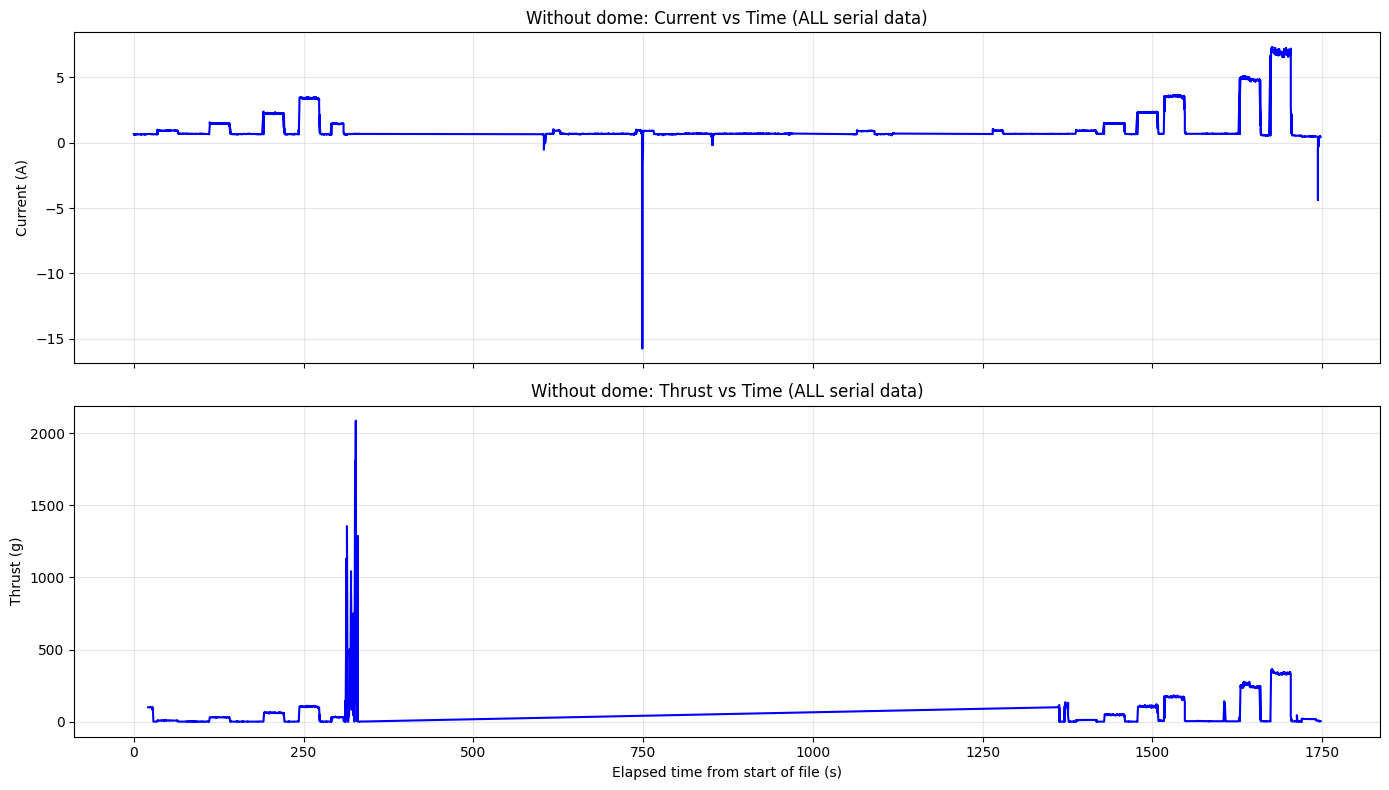

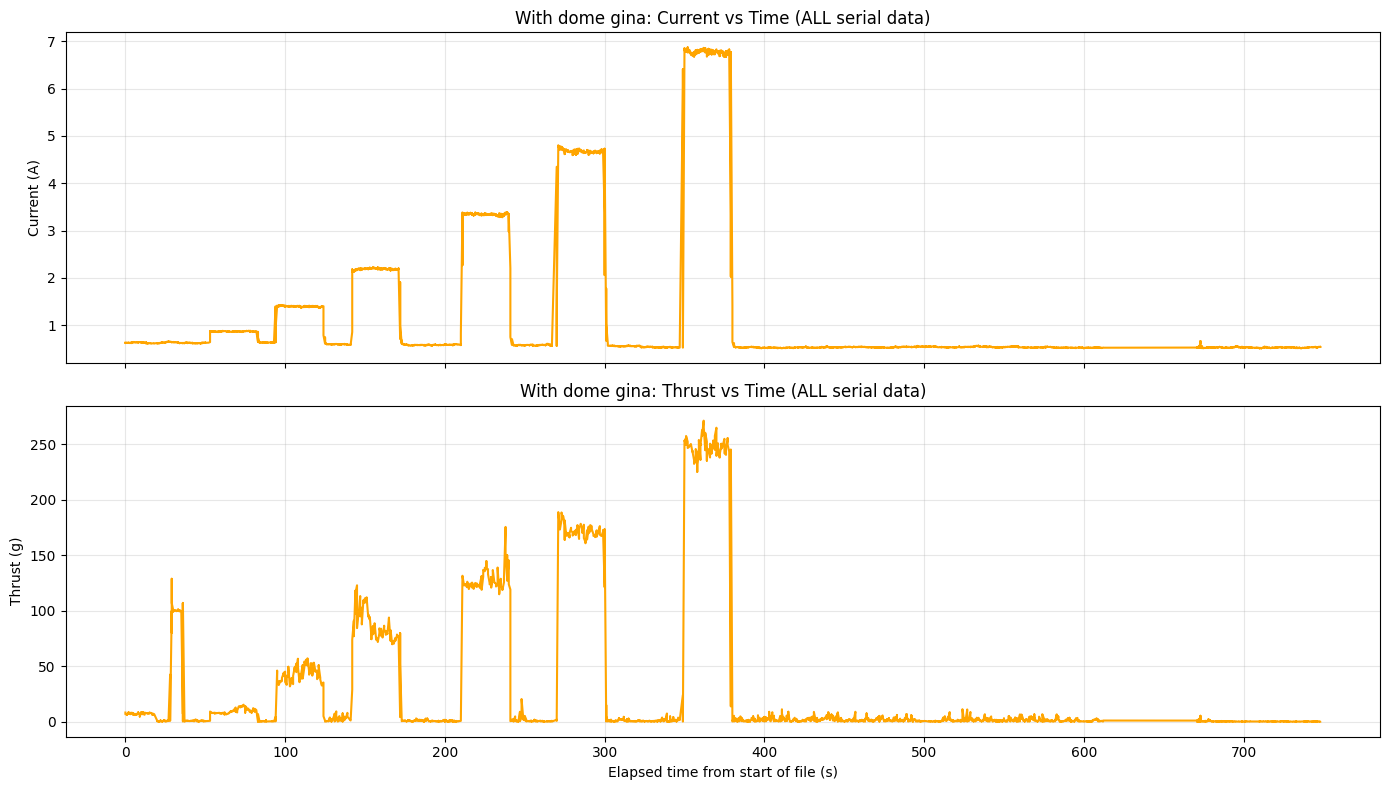

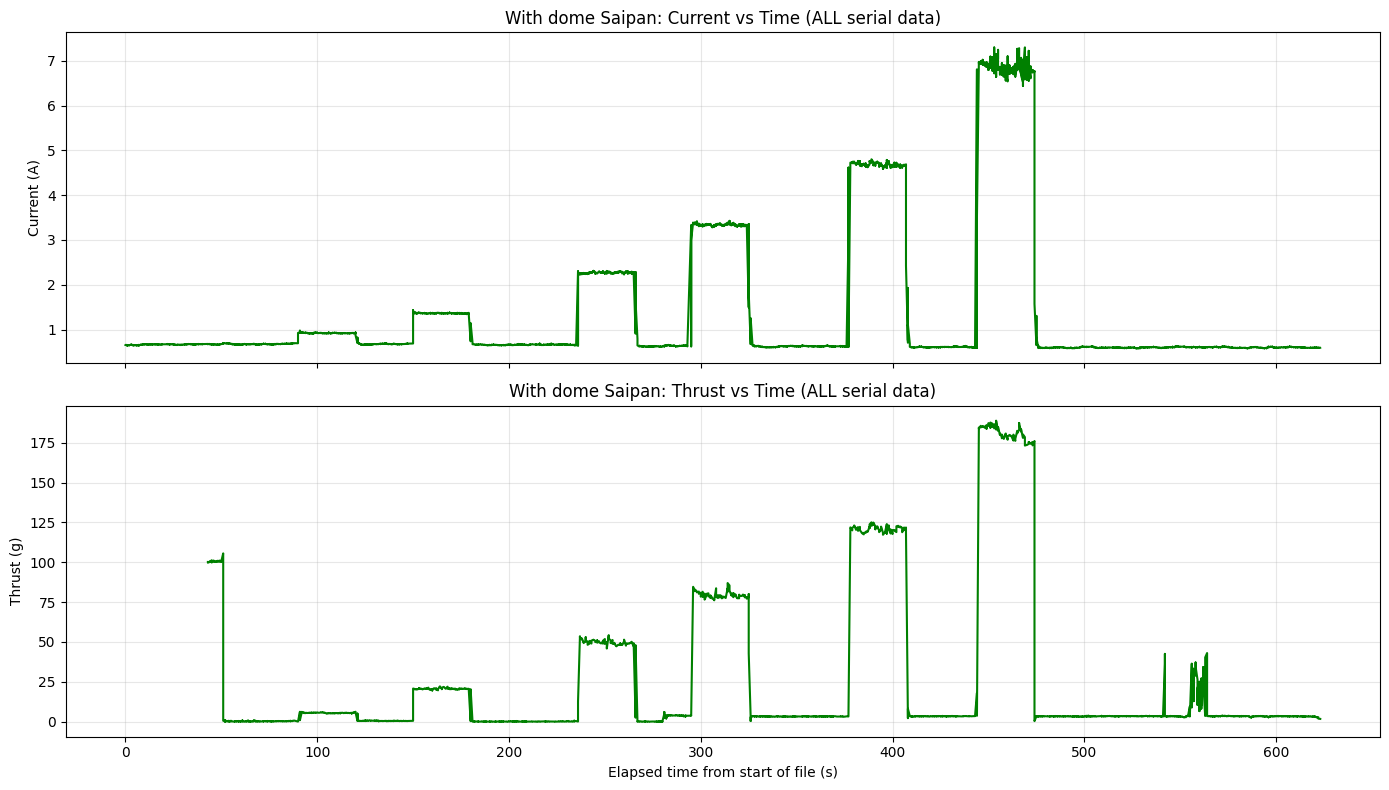

In [95]:
condition_colors = {
    "Without dome": "blue",
    "With dome gina": "orange",
    "With dome Saipan": "green"
}

def parse_plot_csv(path):
    df = pd.read_csv(path)
    df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")

    for col in ["ms", "time_s", "current_a", "thrust_g"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["thrust_abs_g"] = df["thrust_g"].abs()
    return df.sort_values("pc_time").reset_index(drop=True)

def plot_all_serial_timeseries(base_dir):
    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    folders = [p for p in base_dir.iterdir() if p.is_dir()]
    folders = sorted(folders, key=lambda p: condition_order.index(p.name) if p.name in condition_order else 999)

    for folder in folders:
        condition = folder.name
        csv_path = folder / "plot_data.csv"

        if not csv_path.exists():
            print(f"{condition}: missing plot_data.csv")
            continue

        df = parse_plot_csv(csv_path)
        if df.empty:
            print(f"{condition}: no data")
            continue

        df["elapsed_s"] = (df["pc_time"] - df["pc_time"].iloc[0]).dt.total_seconds()

        color = condition_colors.get(condition, None)

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        # 🔵 CURRENT
        axes[0].plot(df["elapsed_s"], df["current_a"], color=color)
        axes[0].set_title(f"{condition}: Current vs Time (ALL serial data)")
        axes[0].set_ylabel("Current (A)")
        axes[0].grid(True, alpha=0.3)

        # 🔵 THRUST
        thrust_df = df[df[thrust_col].notna()].copy()
        axes[1].plot(thrust_df["elapsed_s"], thrust_df[thrust_col], color=color)
        axes[1].set_title(f"{condition}: Thrust vs Time (ALL serial data)")
        axes[1].set_xlabel("Elapsed time from start of file (s)")
        axes[1].set_ylabel("Thrust (g)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

plot_all_serial_timeseries(base_dir)

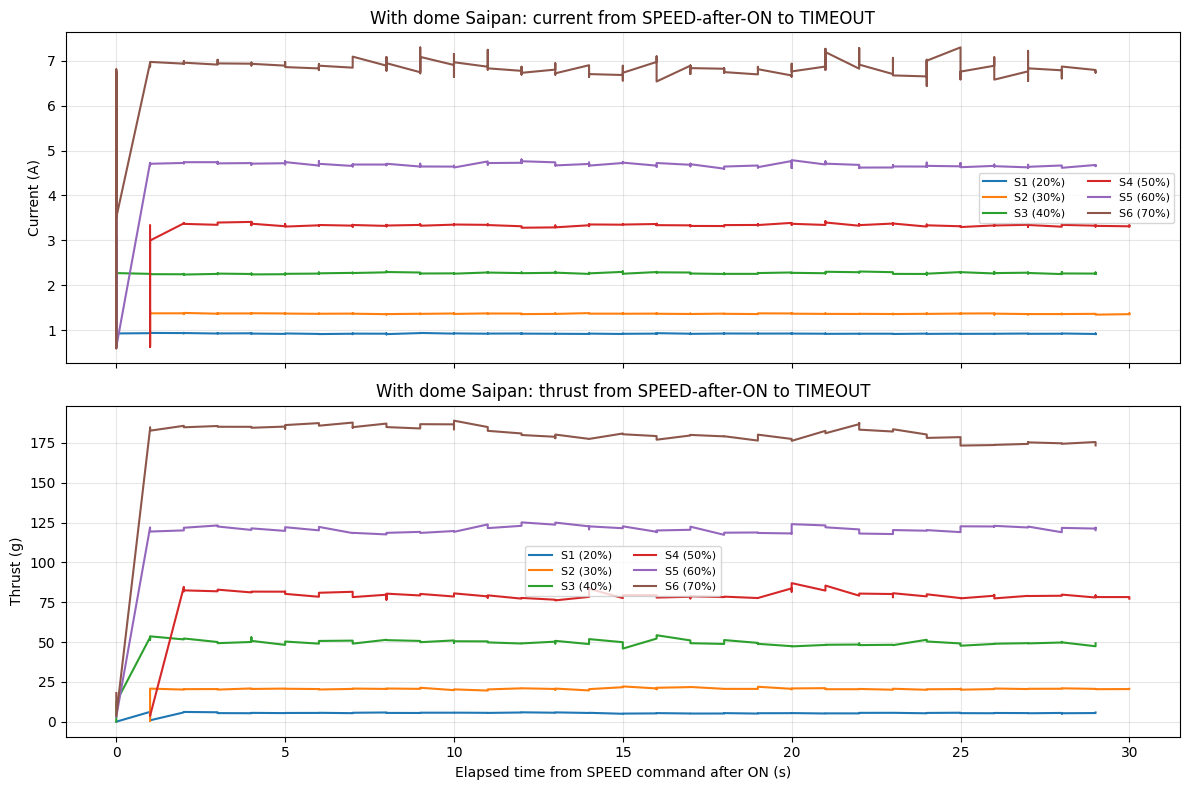

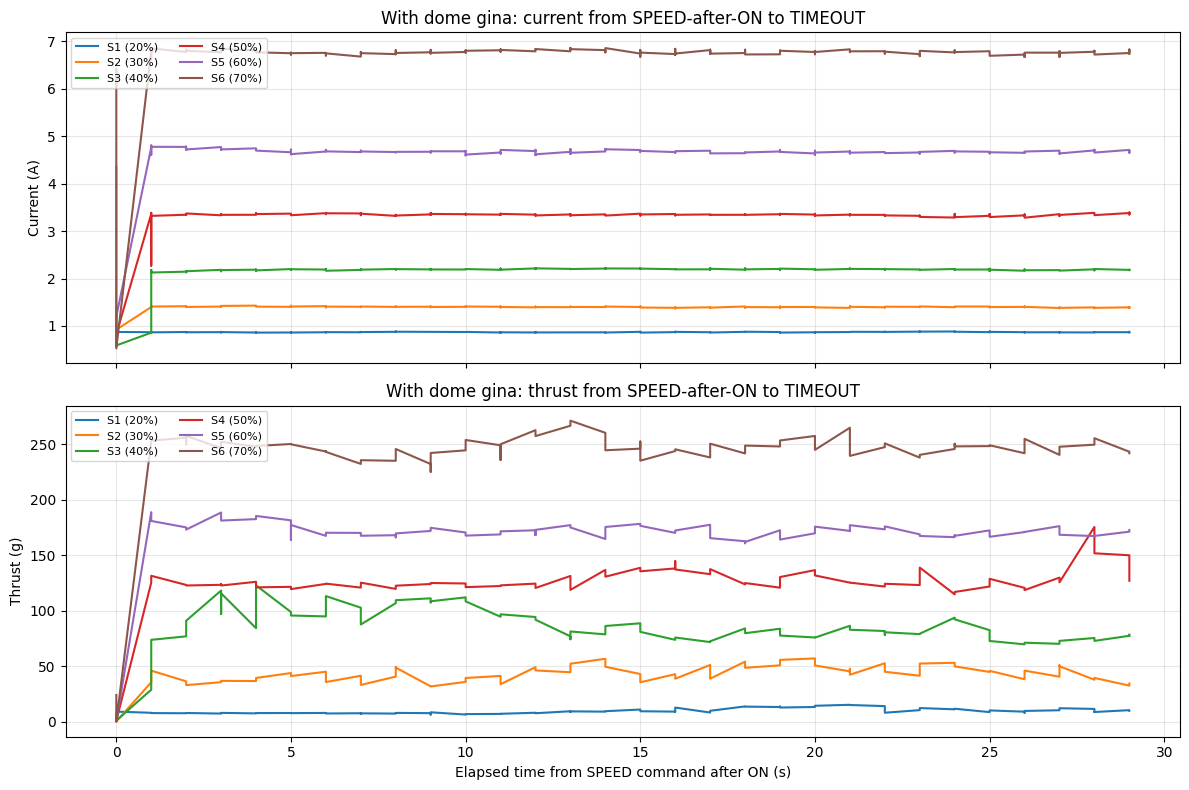

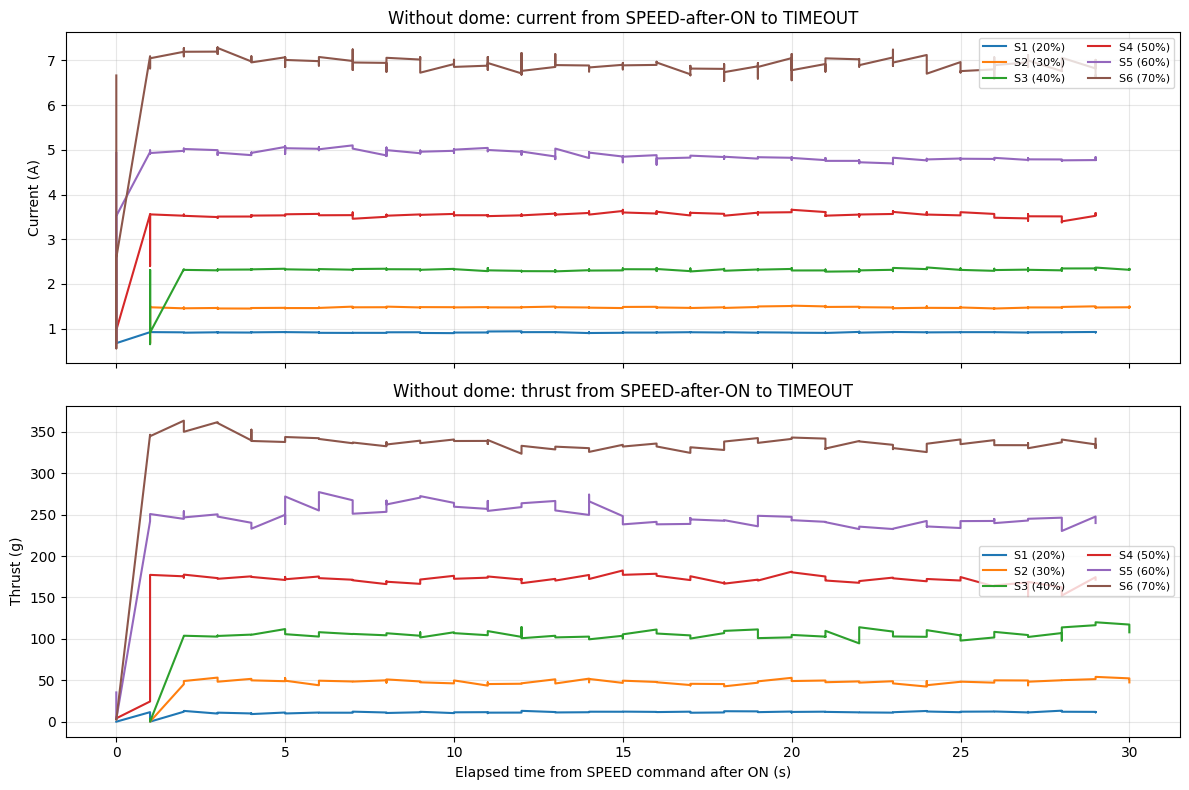

In [98]:
def plot_raw_timeseries(raw_interest):
    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    for condition, df in raw_interest.items():
        if df.empty:
            continue

        # Must have session info
        if "control_session_id" not in df.columns or "segment_start_ts" not in df.columns:
            print(f"Skipping {condition}: raw_interest does not contain control-session start info.")
            continue

        fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # Plot EACH session separately
        for session_id, grp in df.groupby("control_session_id"):
            grp = grp.sort_values("pc_time").copy()

            # Recompute x directly from SPEED-after-ON start timestamp
            grp["elapsed_s"] = (grp["pc_time"] - grp["segment_start_ts"]).dt.total_seconds()

            speed = grp["speed_pct"].iloc[0] if "speed_pct" in grp.columns and grp["speed_pct"].notna().any() else np.nan
            label = f"S{session_id} ({int(speed)}%)" if pd.notna(speed) else f"S{session_id}"

            axes[0].plot(grp["elapsed_s"], grp["current_a"], label=label)

            thrust_part = grp[grp[thrust_col].notna()]
            axes[1].plot(thrust_part["elapsed_s"], thrust_part[thrust_col], label=label)

        axes[0].set_title(f"{condition}: current from SPEED-after-ON to TIMEOUT")
        axes[0].set_ylabel("Current (A)")
        axes[0].grid(True, alpha=0.3)

        axes[1].set_title(f"{condition}: thrust from SPEED-after-ON to TIMEOUT")
        axes[1].set_xlabel("Elapsed time from SPEED command after ON (s)")
        axes[1].set_ylabel("Thrust (g)")
        axes[1].grid(True, alpha=0.3)

        axes[0].legend(fontsize=8, ncol=2)
        axes[1].legend(fontsize=8, ncol=2)

        plt.tight_layout()
        plt.show()

plot_raw_timeseries(raw_interest)

KeyError: 'last_speed_pct'

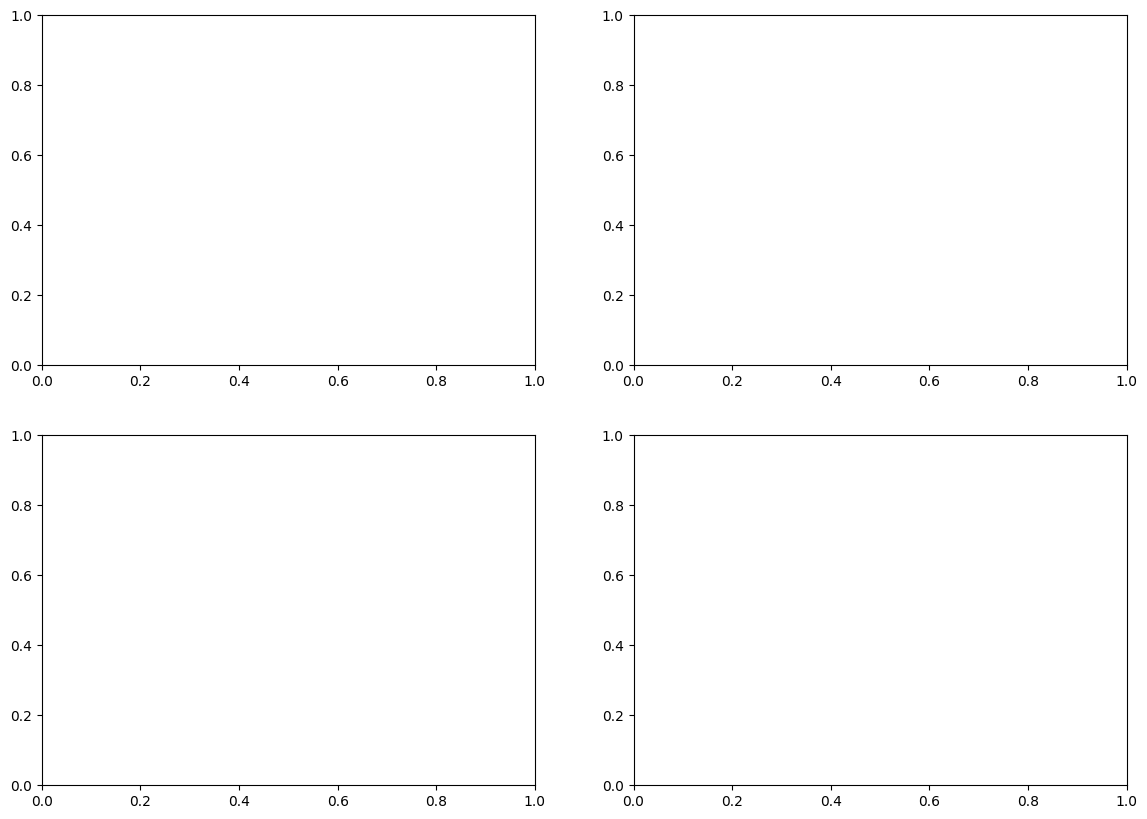

In [97]:
def ordered_conditions(df, column="condition"):
    existing = list(df[column].dropna().unique())
    ordered = [c for c in condition_order if c in existing]
    ordered += [c for c in existing if c not in ordered]
    return ordered

def plot_compare_lines(per_speed_df):
    if per_speed_df.empty:
        print("No per-speed data available.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    specs = [
        ("thrust_mean_g_weighted", "Mean thrust (g)", "Mean thrust vs Speed"),
        ("current_mean_A_weighted", "Mean current (A)", "Mean current vs Speed"),
        ("efficiency_g_per_A_weighted", "Efficiency (g/A)", "Efficiency vs Speed"),
        ("thrust_peak_g_max", "Peak thrust (g)", "Peak thrust vs Speed"),
    ]

    ordered = ordered_conditions(per_speed_df)

    for ax, (col, ylabel, title) in zip(axes, specs):
        for condition in ordered:
            grp = per_speed_df[per_speed_df["condition"] == condition].sort_values("last_speed_pct")
            if len(grp):
                ax.plot(grp["last_speed_pct"], grp[col], marker="o", label=condition)
        ax.set_xlabel("Speed command in session (%)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    plt.tight_layout()
    plt.show()

plot_compare_lines(per_speed_df)

KeyError: 'last_speed_pct'

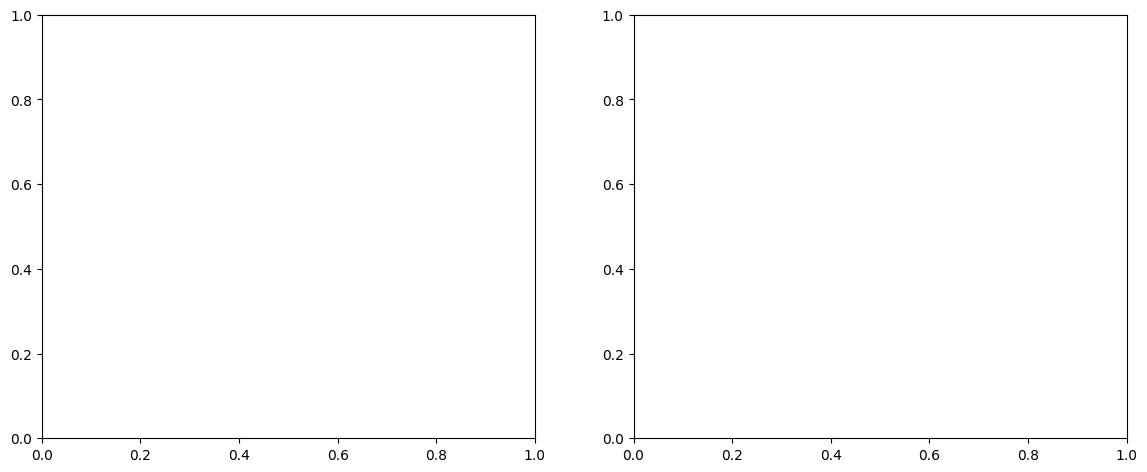

In [ ]:
def plot_scatter_thrust_vs_current(per_speed_df):


    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
   
    ordered_speed = ordered_conditions(per_speed_df) if not per_speed_df.empty else []



    if not per_speed_df.empty:
        for condition in ordered_speed:
            grp = per_speed_df[per_speed_df["condition"] == condition].sort_values("last_speed_pct")
            axes[1].scatter(grp["current_mean_A_weighted"], grp["thrust_mean_g_weighted"], s=90, label=condition)
            for _, row in grp.iterrows():
                axes[1].annotate(f'{int(row["last_speed_pct"])}%', (row["current_mean_A_weighted"], row["thrust_mean_g_weighted"]),
                                 textcoords="offset points", xytext=(4, 4), fontsize=8)
        axes[1].set_title("Thrust vs current (per speed summary)")
        axes[1].set_xlabel("Weighted mean current (A)")
        axes[1].set_ylabel("Weighted mean thrust (g)")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_scatter_thrust_vs_current(per_speed_df)